### Analysis playground for Classifier-Free Guidance

In [2]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

import robomimic
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils
import robomimic.dev.hparam.metrics.smoothness_metrics as SmoothnessMetrics
import robomimic.dev.hparam.metrics.metric_fn as EvalMetrics
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite, HparamAnalyzer

In [2]:
# User Argument
use_3x_speed = True

In [8]:
result_dir = "/home/wjung85/Repo/projects/FastIL/logs/compare_4x/can"
result_dir = "/home/wjung85/Repo/projects/FastIL/logs/compare_4x/lift"
# result_dir = "/home/wjung85/Repo/projects/FastIL/logs/compare_4x/square"

In [9]:
# Can
inp_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_can_baseline_epoch_1000_guide_inp")
bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_can_baseline_epoch_1000_guide_no_guide")
cfg_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_can_cfg_bm_off_epoch_1000_guide_no_guide")
cfg_inp_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_can_cfg_bm_off_epoch_1000_guide_inp")
cfg_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_can_cfg_bm_off_epoch_1000_guide_cfg")


# # Lift
# inp_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_lift_baseline_epoch_700_guide_inp")
# bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_lift_baseline_epoch_700_guide_no_guide")
# cfg_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_lift_cfg_bm_off_epoch_1000_guide_cfg")
# cfg_inp_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_lift_cfg_bm_off_epoch_1000_guide_inp")
# cfg_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_lift_cfg_bm_off_epoch_1000_guide_no_guide")


# # Square

# inp_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_model_epoch_1000_square_guide_inp")
# cfg_bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_square_cfg_bm_false_model_epoch_1000_guide_no_guide")
# bl_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_model_epoch_1000_square_guide_no_guide")
# cfg_inp_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_square_cfg_bm_false_model_epoch_1000_guide_inp")
# cfg_results = pkl_utils.get_result_pkl_files(result_dir, filter="agent_square_cfg_bm_false_model_epoch_1000_guide_cfg")

In [7]:
print(f"Summary: cfg {len(cfg_results)} cfg_inp {len(cfg_inp_results)} cfg_bl {len(cfg_bl_results)} bl {len(bl_results)} inp_bl {len(inp_bl_results)}")

Summary: cfg 0 cfg_inp 0 cfg_bl 0 bl 0 inp_bl 0


In [3]:
if use_3x_speed:
    # cfg_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x"
    cfg_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_compare_3"
    cfg_new_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_binary_mask_compare_3"
    cfg_results  = pkl_utils.get_result_pkl_files(cfg_new_dir, filter="cfg_weight") # conditioned model, with cfg inference
    cfg_inp_results = pkl_utils.get_result_pkl_files(cfg_new_dir, filter="cfg_inpaint") # conditioned model, with inpainting inference
    cfg_bl_results = pkl_utils.get_result_pkl_files(cfg_new_dir, filter="cfg_bl") # conditioned model, with baseline inference
    bl_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="uncond_baseline") # unconditioned model, with baseline inference
    inp_bl_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="uncond_inpaint") # conditioned model, with inpainting inference
else:
    cfg_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg"
    baseline_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug"
    baseline_inp_dir = "/home/wjung85/Repo/projects/FastIL/logs/hparam/"
    cfg_results  = pkl_utils.get_result_pkl_files(cfg_dir, filter="weight") # conditioned model, with cfg inference
    cfg_inp_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="inp") # conditioned model, with inpainting inference
    cfg_bl_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="bl") # conditioned model, with baseline inference
    bl_results = pkl_utils.get_result_pkl_files(baseline_dir, filter="bl") # unconditioned model, with baseline inference


print(f"Summary: cfg {len(cfg_results)} cfg_inp {len(cfg_inp_results)} cfg_bl {len(cfg_bl_results)} bl {len(bl_results)} inp_bl {len(inp_bl_results)}")

Summary: cfg 3 cfg_inp 3 cfg_bl 3 bl 5 inp_bl 5


## Few Demo Comparison

Compare the predictions of the demo of different models

In [4]:
demo_idx = 6
action_idx = 0
figsize = (6, 3)

In [5]:
cfg_demo = pkl_utils.load_demo_from_pkl(cfg_results[0], demo_idx=demo_idx)
print(cfg_results[0])
cfg_inp_demo = pkl_utils.load_demo_from_pkl(cfg_inp_results[0], demo_idx=demo_idx)
print(cfg_inp_results[0])
cfg_bl_demo = pkl_utils.load_demo_from_pkl(cfg_bl_results[0], demo_idx=demo_idx)
print(cfg_bl_results[0])
bl_demo = pkl_utils.load_demo_from_pkl(bl_results[0], demo_idx=demo_idx)
print(bl_results[0])
bl_inp_demo = pkl_utils.load_demo_from_pkl(inp_bl_results[0], demo_idx=demo_idx)
print(inp_bl_results[0])

/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_binary_mask_compare_3/square_image_cond_cfg_weight_0.3_iter_2_2025-01-23 00:00:07.733472.pkl
/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_binary_mask_compare_3/square_image_cond_cfg_inpaint_iter_2_2025-01-22 22:38:23.074576.pkl
/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_binary_mask_compare_3/square_image_cond_cfg_bl_iter_2_2025-01-22 23:18:59.301142.pkl
/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_compare_3/square_image_uncond_baseline_iter_4_2025-01-22 14:10:51.151107.pkl
/home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_compare_3/square_image_uncond_inpaint_iter_4_2025-01-22 16:17:50.178246.pkl


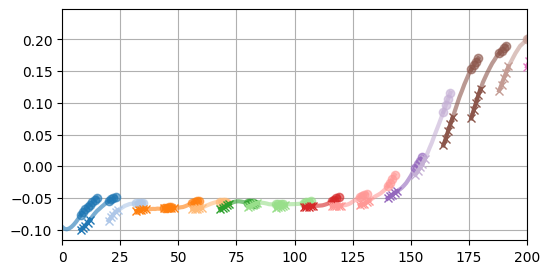

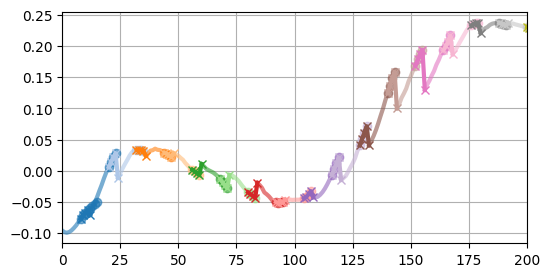

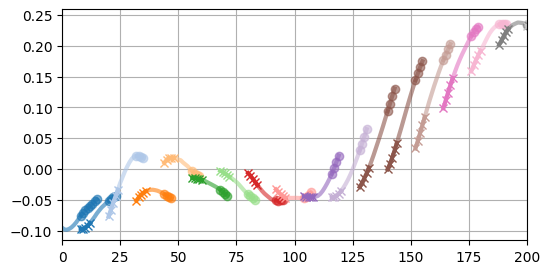

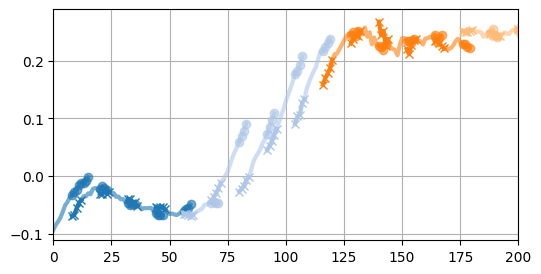

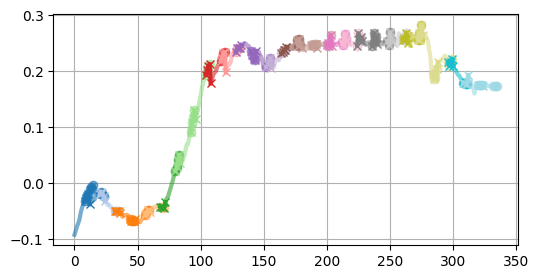

In [18]:
_ = plot_utils.plot_predictions(cfg_demo, action_idx=action_idx, figsize=figsize, xlim=(0, 200))
_ = plot_utils.plot_predictions(cfg_inp_demo, action_idx=action_idx, figsize=figsize, xlim=(0, 200))
_ = plot_utils.plot_predictions(cfg_bl_demo, action_idx=action_idx, figsize=figsize, xlim=(0, 200))
_ = plot_utils.plot_predictions(bl_demo, action_idx=action_idx, figsize=figsize, xlim=(0, 200))
_ = plot_utils.plot_predictions(bl_inp_demo, action_idx=action_idx, figsize=figsize)

## Hparam Analysis: CFG

This analysis is intendend to find the best hyperparameter for each representative.

In [12]:
from robomimic.dev.hparam.eval_suite import HparamParser, HparamAnalyzer

hparam_parser = HparamParser(param_patterns = {
        'eta': r'eta_(\d+)',
        'weight': r'weight_(\d+\.?\d*)',
        'iter': r'iter_(\d+)'
    })

hparam_analyzer_sparc_del = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="weight", metric_name="smoothness", 
                                        eval_fn = lambda x: np.quantile(Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4), 0.25),
                                        level="demo")

hparam_analyzer_sparc_abs = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="weight", metric_name="smoothness", 
                                        eval_fn = lambda x: np.quantile(Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4), 0.25), 
                                        level="demo")

hparam_analyzer_delta = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="weight", metric_name="smoothness", 
                                        eval_fn = lambda x: np.quantile(Metrics.switch_delta_eval_fn(x), 0.5), 
                                        level="demo")

hparam_analyzer_success = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="weight", metric_name="success", eval_fn=Metrics.average_success_eval_fn, level="stat")


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter weight


100%|██████████| 36/36 [00:52<00:00,  1.45s/it]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter weight


100%|██████████| 36/36 [00:45<00:00,  1.26s/it]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter weight


100%|██████████| 36/36 [00:23<00:00,  1.55it/s]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter weight


100%|██████████| 36/36 [00:22<00:00,  1.58it/s]


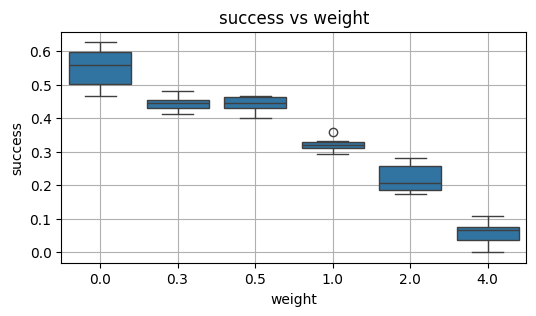

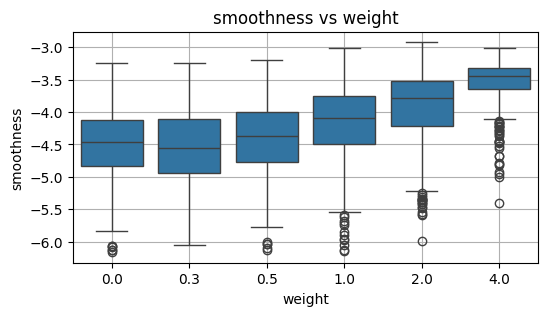

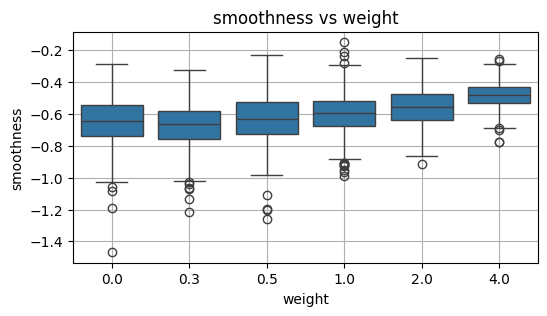

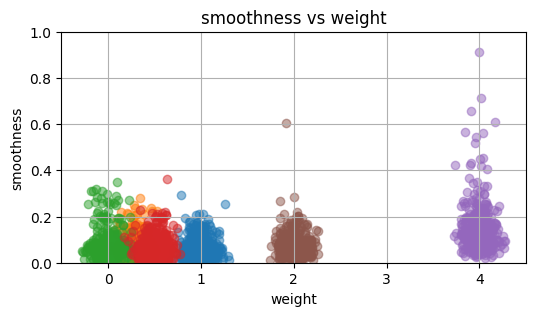

In [14]:
_ = hparam_analyzer_success.plot_hparam_comparison("weight", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_sparc_abs.plot_hparam_comparison("weight", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_sparc_del.plot_hparam_comparison("weight", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_delta.plot_hparam_comparison("weight", figsize=(6, 3), ylim=(0, 1))

## Hparam Analysis: CFG + Inpainting

In [15]:
from robomimic.dev.hparam.eval_suite import HparamParser, HparamAnalyzer

hparam_parser = HparamParser(param_patterns = {
        'eta': r'eta_(\d+)',
        'nres': r'nres_(\d+)',
        'iter': r'iter_(\d+)'
    })

hparam_analyzer_sparc_del = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="inp", metric_name="smoothness", 
                                        eval_fn = lambda x: np.quantile(Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4), 0.25),
                                        level="demo")

hparam_analyzer_sparc_abs = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="inp", metric_name="smoothness", 
                                        eval_fn = lambda x: np.quantile(Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4), 0.25), 
                                        level="demo")

hparam_analyzer_delta = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="inp", metric_name="delta", 
                                        eval_fn = lambda x: np.quantile(Metrics.switch_delta_eval_fn(x), 0.5), 
                                        level="demo")

hparam_analyzer_success = HparamAnalyzer(result_dir = cfg_dir, hparam_parser = hparam_parser, filter="inp", metric_name="success", eval_fn=Metrics.average_success_eval_fn, level="stat")

Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter inp


100%|██████████| 18/18 [00:20<00:00,  1.13s/it]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter inp


100%|██████████| 18/18 [00:17<00:00,  1.00it/s]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter inp


100%|██████████| 18/18 [00:08<00:00,  2.04it/s]


Processing /home/wjung85/Repo/projects/FastIL/logs/hparam_cfg_3x with filter inp


100%|██████████| 18/18 [00:08<00:00,  2.08it/s]


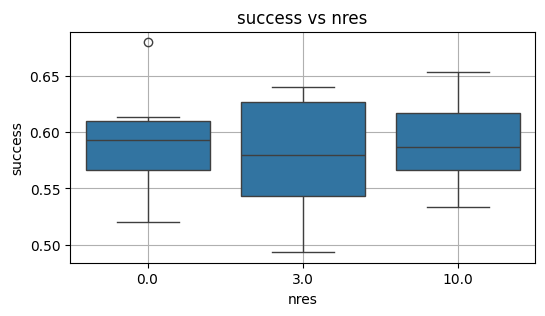

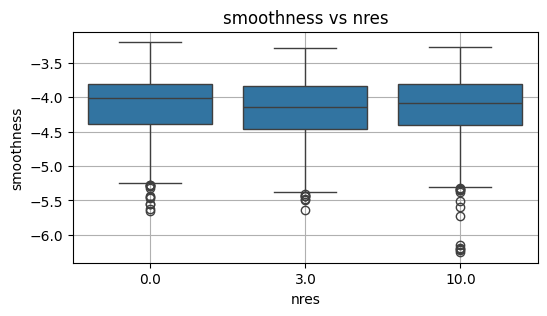

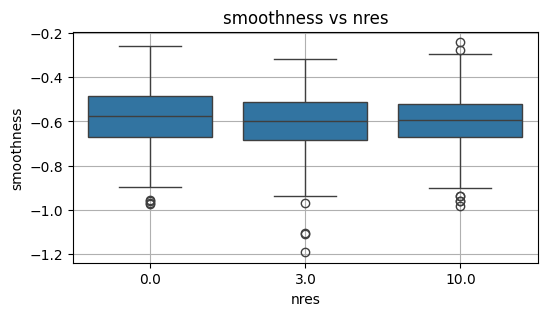

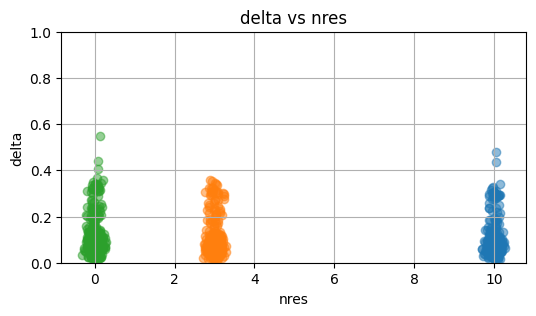

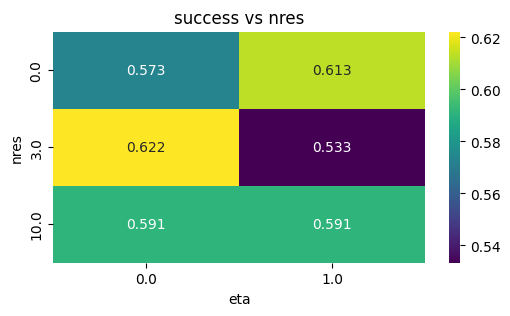

In [16]:
_ = hparam_analyzer_success.plot_hparam_comparison("nres", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_sparc_abs.plot_hparam_comparison("nres", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_sparc_del.plot_hparam_comparison("nres", figsize=(6, 3), plot_type="box")
_ = hparam_analyzer_delta.plot_hparam_comparison("nres", figsize=(6, 3), ylim=(0, 1))
_ = hparam_analyzer_success.plot_hparam_comparison("nres", y_param="eta", figsize=(6, 3), plot_type="box")

## Statistical Analysis

This analysis includes the analysis on success rate, comparison, and smoothness.

In [10]:
cfg_results  = pkl_utils.get_result_pkl_files(cfg_dir, filter="weight_0.0")
cfg_inp_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="nres_3") # conditioned model, with inpainting inference
# cfg_bl_results = pkl_utils.get_result_pkl_files(cfg_dir, filter="bl") # conditioned model, with baseline inference
# bl_results = pkl_utils.get_result_pkl_files(baseline_dir, filter="bl") # unconditioned model, with baseline inference

NameError: name 'cfg_dir' is not defined

In [11]:
# cfg (best hparam)
analyzer= DemoEvalSuite(cfg_results, Metrics.success_eval_fn, metric_name="success")
# analyzer.add_metric("sparc_delta", lambda x: Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer.add_metric("sparc_abs", lambda x: Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer.add_metric("delta", lambda x: Metrics.switch_delta_eval_fn(x))
# analyzer.aggregate_metric(metric_name="sparc_delta", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer.aggregate_metric(metric_name="sparc_abs", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer.aggregate_metric(metric_name="delta", agg_suffix_name = "q75", agg_fn = lambda x: np.quantile(x, 0.75))


# inpainting (best hparam)
analyzer_inp = DemoEvalSuite(cfg_inp_results, Metrics.success_eval_fn, metric_name="success")
# analyzer_inp.add_metric("sparc_delta", lambda x: Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_inp.add_metric("sparc_abs", lambda x: Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_inp.add_metric("delta", lambda x: Metrics.switch_delta_eval_fn(x))
# analyzer_inp.aggregate_metric(metric_name="sparc_delta", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_inp.aggregate_metric(metric_name="sparc_abs", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_inp.aggregate_metric(metric_name="delta", agg_suffix_name = "q75", agg_fn = lambda x: np.quantile(x, 0.75))

# cfg + bl
analyzer_cfg_bl = DemoEvalSuite(cfg_bl_results, Metrics.success_eval_fn, metric_name="success")
# analyzer_cfg_bl.add_metric("sparc_delta", lambda x: Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_cfg_bl.add_metric("sparc_abs", lambda x: Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_cfg_bl.add_metric("delta", lambda x: Metrics.switch_delta_eval_fn(x))
# analyzer_cfg_bl.aggregate_metric(metric_name="sparc_delta", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_cfg_bl.aggregate_metric(metric_name="sparc_abs", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_cfg_bl.aggregate_metric(metric_name="delta", agg_suffix_name = "q75", agg_fn = lambda x: np.quantile(x, 0.75))

# baseline
analyzer_bl = DemoEvalSuite(bl_results, Metrics.success_eval_fn, metric_name="success")
# analyzer_bl.add_metric("sparc_delta", lambda x: Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_bl.add_metric("sparc_abs", lambda x: Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_bl.add_metric("delta", lambda x: Metrics.switch_delta_eval_fn(x))
# analyzer_bl.aggregate_metric(metric_name="sparc_delta", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_bl.aggregate_metric(metric_name="sparc_abs", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_bl.aggregate_metric(metric_name="delta", agg_suffix_name = "q75", agg_fn = lambda x: np.quantile(x, 0.75))

analyzer_inp_bl = DemoEvalSuite(inp_bl_results, Metrics.success_eval_fn, metric_name="success")
# analyzer_inp_bl.add_metric("sparc_delta", lambda x: Metrics.sparc_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_inp_bl.add_metric("sparc_abs", lambda x: Metrics.sparc_absolute_sliding_window_eval_fn(x, sliding_window_size=4))
# analyzer_inp_bl.add_metric("delta", lambda x: Metrics.switch_delta_eval_fn(x))
# analyzer_inp_bl.aggregate_metric(metric_name="sparc_delta", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_inp_bl.aggregate_metric(metric_name="sparc_abs", agg_suffix_name = "q25", agg_fn = lambda x: np.quantile(x, 0.25))
# analyzer_inp_bl.aggregate_metric(metric_name="delta", agg_suffix_name = "q75", agg_fn = lambda x: np.quantile(x, 0.75))


100%|██████████| 3/3 [00:00<00:00, 12.54it/s]


In [12]:
print(f"CFG Best: Min {analyzer.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"CFG + Inpainting: Min {analyzer_inp.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_inp.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_inp.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"CFG + BL: Min {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_cfg_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"BL: Min {analyzer_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")
print(f"Inpainting + BL: Min {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().min():.2f} Mean {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().mean():.2f} Max {analyzer_inp_bl.df.groupby(by='result_idx')['success'].mean().max():.2f}")


CFG Best: Min 0.96 Mean 0.96 Max 0.96
CFG + Inpainting: Min 0.88 Mean 0.89 Max 0.90
CFG + BL: Min 0.92 Mean 0.93 Max 0.94
BL: Min 1.00 Mean 1.00 Max 1.00
Inpainting + BL: Min 0.96 Mean 0.97 Max 0.98


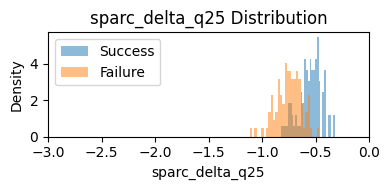

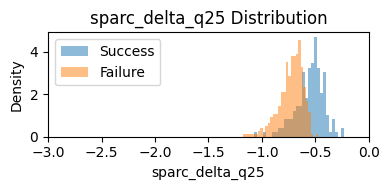

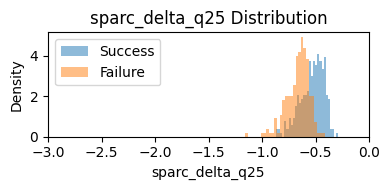

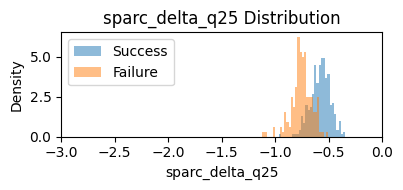

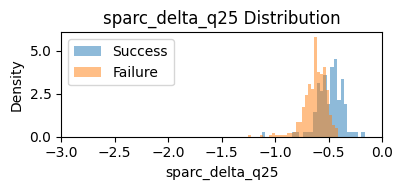

In [13]:
analyzer.plot_metric_histogram_by_success("sparc_delta_q25", figsize=(4, 2), xlim=(-3, 0))
analyzer_bl.plot_metric_histogram_by_success("sparc_delta_q25", figsize=(4, 2), xlim=(-3, 0))
analyzer_inp.plot_metric_histogram_by_success("sparc_delta_q25", figsize=(4, 2), xlim=(-3, 0))
analyzer_cfg_bl.plot_metric_histogram_by_success("sparc_delta_q25", figsize=(4, 2), xlim=(-3, 0))
analyzer_inp_bl.plot_metric_histogram_by_success("sparc_delta_q25", figsize=(4, 2), xlim=(-3, 0))

In [10]:
analyzer.plot_metric_histogram_by_success("sparc_abs_q25", figsize=(4, 2), xlim=(-10, -1))
analyzer_bl.plot_metric_histogram_by_success("sparc_abs_q25", figsize=(4, 2), xlim=(-10, -1))
analyzer_inp.plot_metric_histogram_by_success("sparc_abs_q25", figsize=(4, 2), xlim=(-10, -1))
analyzer_cfg_bl.plot_metric_histogram_by_success("sparc_abs_q25", figsize=(4, 2), xlim=(-10, -1))
analyzer_inp_bl.plot_metric_histogram_by_success("sparc_abs_q25", figsize=(4, 2), xlim=(-10, -1))

KeyError: 'sparc_abs_q25'

<Figure size 400x200 with 0 Axes>

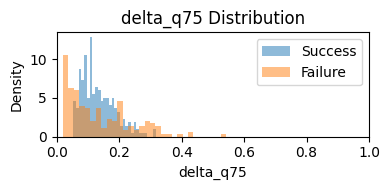

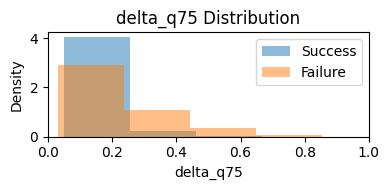

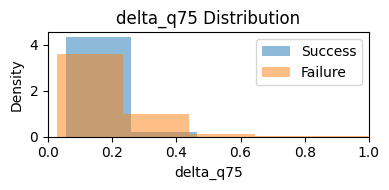

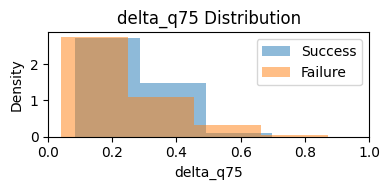

In [24]:
analyzer.plot_metric_histogram_by_success("delta_q75", figsize=(4, 2), xlim=(0, 1))
analyzer_bl.plot_metric_histogram_by_success("delta_q75", figsize=(4, 2), xlim=(0, 1))
analyzer_inp.plot_metric_histogram_by_success("delta_q75", figsize=(4, 2), xlim=(0, 1))
analyzer_cfg_bl.plot_metric_histogram_by_success("delta_q75", figsize=(4, 2), xlim=(0, 1))
analyzer_inp_bl.plot_metric_histogram_by_success("delta_q75", figsize=(4, 2), xlim=(0, 1))

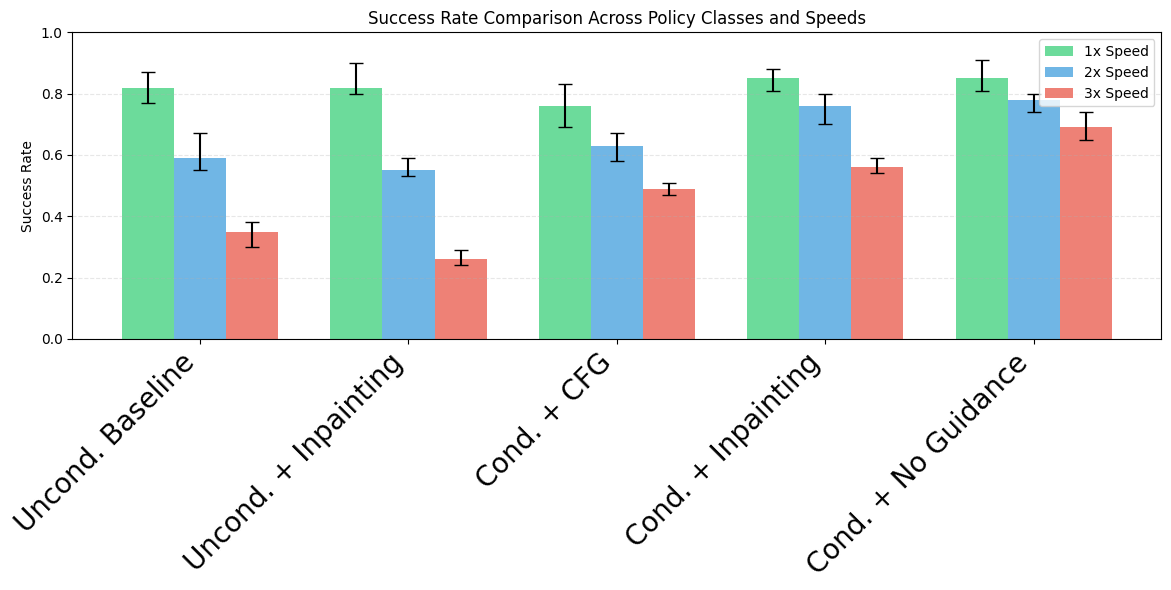

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Data preparation
labels = [
    'Uncond. Baseline',
    'Uncond. + Inpainting',
    'Cond. + CFG',
    'Cond. + Inpainting',
    'Cond. + No Guidance'
]

# Data structure: [min, mean, max] for each speed
data_3x = [
    [0.30, 0.35, 0.38],  # Baseline
    [0.24, 0.26, 0.29],  # Uncond + Inpainting
    [0.47, 0.49, 0.51],  # Cond + CFG
    [0.54, 0.56, 0.59],  # Cond + Inpainting
    [0.65, 0.69, 0.74]   # Cond + No guidance
]

data_2x = [
    [0.55, 0.59, 0.67],
    [0.53, 0.55, 0.59],
    [0.58, 0.63, 0.67],
    [0.70, 0.76, 0.80],
    [0.74, 0.78, 0.80]
]

data_1x = [
    [0.77, 0.82, 0.87],
    [0.80, 0.82, 0.90],  # No data for 1x
    [0.69, 0.76, 0.83],
    [0.81, 0.85, 0.88],
    [0.81, 0.85, 0.91]
]

# Create figure
plt.figure(figsize=(12, 6))

# Position calculations
x = np.arange(len(labels))
width = 0.25  # Width of bars

# Plot bars for each speed
for i, (speed_data, offset, color, label) in enumerate([
    (data_1x, -width, '#2ecc71', '1x Speed'),
    (data_2x, 0, '#3498db', '2x Speed'),
    (data_3x, width, '#e74c3c', '3x Speed')
]):
    means = [d[1] if d[1] is not None else np.nan for d in speed_data]
    yerr_minus = [d[1] - d[0] if d[1] is not None else np.nan for d in speed_data]
    yerr_plus = [d[2] - d[1] if d[1] is not None else np.nan for d in speed_data]
    
    plt.bar(x + offset, means, width, label=label, color=color, alpha=0.7)
    plt.errorbar(x + offset, means, yerr=[yerr_minus, yerr_plus], 
                fmt='none', color='black', capsize=5)

# Customize plot
plt.ylabel('Success Rate')
plt.title('Success Rate Comparison Across Policy Classes and Speeds')
plt.xticks(x, labels, rotation=45, ha='right', fontsize=20)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend()

# Set y-axis limits
plt.ylim(0, 1.0)

# Adjust layout
plt.tight_layout()

plt.show()